First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

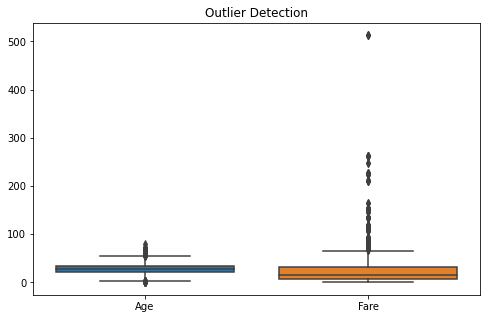


Preprocessed Dataset:
   Survived  Pclass  Sex       Age  SibSp  Parch      Fare  Embarked
0         0       3    1 -0.607611      1      0 -0.751265         2
2         1       3    0 -0.207827      0      0 -0.700265         2
3         1       1    0  0.691688      1      0  2.712961         2
4         0       3    1  0.691688      0      0 -0.690821         2
5         0       3    1 -0.007934      0      0 -0.659971         1

Final Shape: (718, 8)

Data preprocessing completed successfully!


In [1]:
# Task 1: Data Cleaning & Preprocessing
# Dataset: Titanic Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load dataset
df = pd.read_csv("Titanic-Dataset.csv")

# Display basic information
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Handle missing values
# Fill Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column due to many missing values
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

# Drop rows with missing Fare values
df.dropna(inplace=True)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# Convert categorical variables into numerical
le = LabelEncoder()

categorical_columns = ['Sex', 'Embarked']
for col in categorical_columns:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

# Remove unnecessary columns
columns_to_drop = ['Name', 'Ticket', 'PassengerId']
for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

# Visualize outliers
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Age', 'Fare']])
plt.title("Outlier Detection")
plt.show()

# Remove outliers using IQR
numeric_cols = ['Age', 'Fare']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

# Standardization
scaler = StandardScaler()

numerical_features = ['Age', 'Fare']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

print("\nPreprocessed Dataset:")
print(df.head())

print("\nFinal Shape:", df.shape)

# Save cleaned dataset
df.to_csv("cleaned_titanic.csv", index=False)

print("\nData preprocessing completed successfully!")
